# **ThermoClock: adding timing to the ThermoModel bands**

The bands of `1i.ThermoModel_v2` answer *how high and how low*. They say nothing about *when*. The cycle work in `2a.Cycles` answers the opposite question and says nothing about price. Put together they produce something neither gives alone: a **dated price path**.

## The construction

1. **The clock.** The same clock `2a.Cycles` draws: every cycle has the same length, with the period and phase fitted by least squares on the observed tops *and* bottoms together, and each bottom a quarter of a cycle after its top. The best period is **1419 days**. Every date gets a phase: 0 at a cycle top, 1 at the next, bottoms at **0.25** - the cycle is asymmetric, roughly a year down and three years back up. The 2011 cycle (910 days top to top) is left out of the fit as the outlier it is.

   The fit balances all eight extremes rather than trusting any one of them. It lands within 8-43 days of the tops and of the first three bottoms, but the July 2026 bottom came 65 days ahead of it: the 2026 bear market lasted only 268 days, against 363-410 before, and no single fixed period can land on it without missing everything else.

2. **The link.** For each slice of the cycle, where in the ThermoModel corridor did price actually sit? Measured per cycle rather than pooled, so disagreement between cycles stays visible instead of being averaged away.

3. **The projection.** The corridor at a future date (the bands are pure functions of time, so they extend exactly) combined with the historical position at that phase gives an expected price; the spread across cycles gives an envelope.

## Does it hold up?

The profile chart is the test. Every cycle starts high after a top, bottoms out near phase 0.25, and climbs back - the shape genuinely repeats, and the per-cycle curves correlate between 0.55 and 0.78.

**Where it is tight and where it is not.** Near the extremes the cycles agree closely: an interquartile spread of 5-11 percentage points around the top and 8-9 just after the bottom. Through the climb they do not - the spread reaches 45 points late in the ascent, because how fast price climbs out of a bear market has varied a lot. Read the dated *extremes* with some confidence and the *path between them* with less.

One further caveat on the price envelope: it reflects only uncertainty about position within the corridor. It assumes the corridor itself and the timing are both right. Each carries its own error, and neither is inside that shaded band.

✅ BTC data fetched from CoinMetrics: 6351 rows (last: 2026-05-24)


🔄 BTC PriceUSD topped up with Yahoo Finance through 2026-09-23 (123 extra day(s)); other on-chain fields carried forward from 2026-05-23


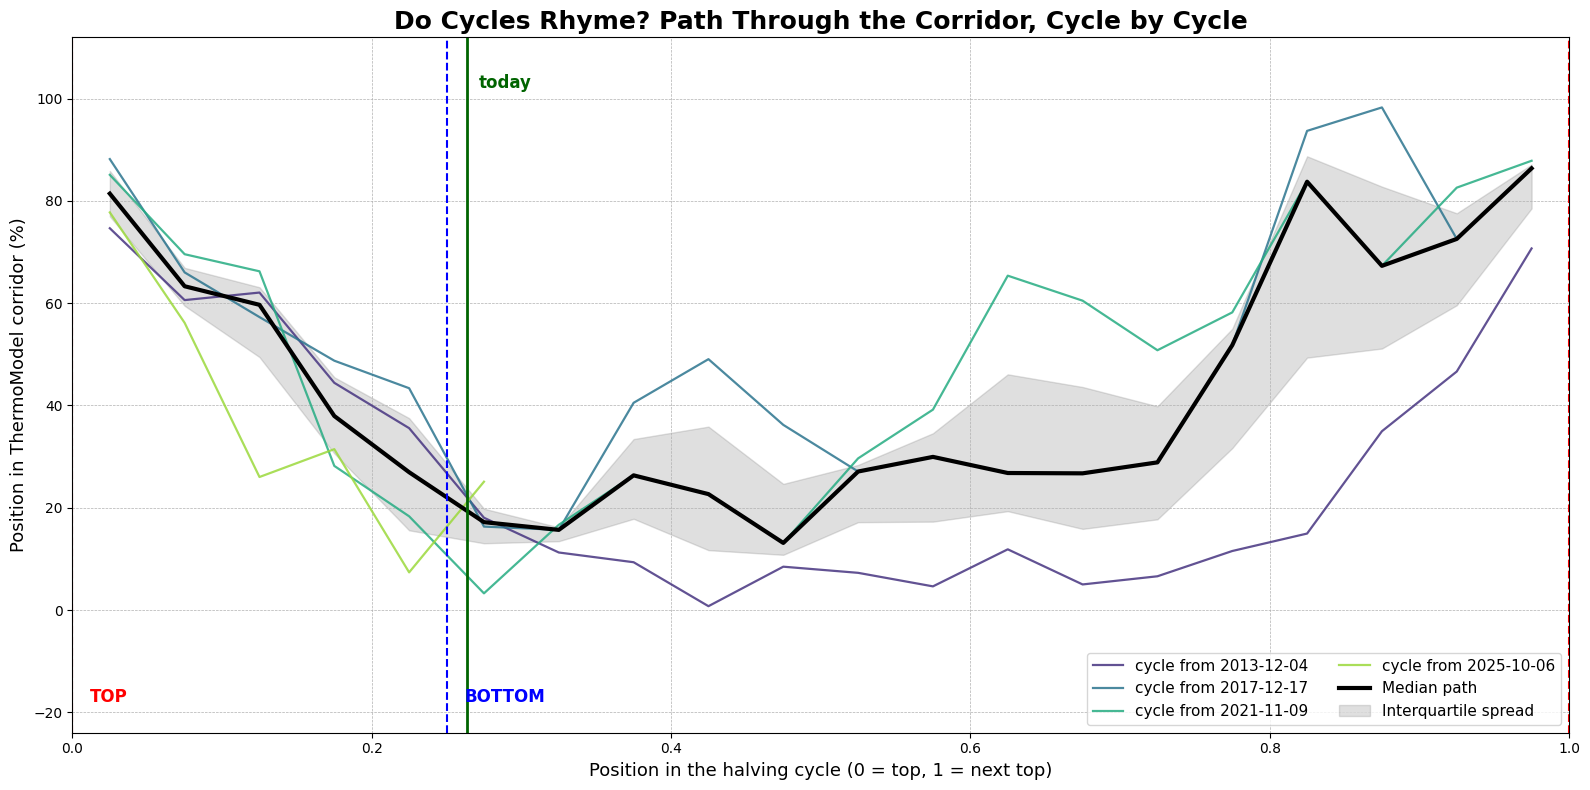

In [1]:
import sys
import sys, os
_base = os.getcwd()
while _base and not os.path.isdir(os.path.join(_base, 'functions')):
    _parent = os.path.dirname(_base)
    if _parent == _base: break
    _base = _parent
if os.path.abspath(_base) not in sys.path:
    sys.path.insert(0, os.path.abspath(_base))
from functions.functions_ThermoModel2 import load_dataframe
from functions.functions_ThermoClock import (
    add_cycle_phase,
    fit_phase_profile,
    project_cycle_path,
    plot_phase_profile,
    plot_cycle_forecast,
    cycle_calls,
)
import warnings
warnings.filterwarnings("ignore")

df_cycle, params_cycle = load_dataframe(extend_days=1250)
df_cycle = add_cycle_phase(df_cycle)
profile = fit_phase_profile(df_cycle)
df_cycle = project_cycle_path(df_cycle, profile)

plot_phase_profile(df_cycle, profile)

## The combined forecast

The chart below adds one new object to the corridor: the **orange line**, a cycle-implied price path. It is not a regression on price. It is a lookup: *at this point of the cycle, where in the corridor has price usually sat?* - converted into dollars using the corridor of that date. Four steps, stated exactly.

### 1. Position in the corridor

With $P(t)$ the price and $L(t)$, $U(t)$ the lower and upper bands, the position of price inside the corridor is

$$o(t) = \frac{\log_{10} P(t) - \log_{10} L(t)}{\log_{10} U(t) - \log_{10} L(t)}$$

so $o = 0$ sits on the lower band and $o = 1$ on the upper band. The bands are built on the log-log trend $\ell(t) = a + b\,L + q\,L^2$ with $L = \log_{10} t$ ($t$ = days since genesis) - a power law whose exponent eases off with time, see `1i.ThermoModel_v2` - and the cycle position $c(t) = t/1458$:

$$\log_{10} L(t) = \ell(t) + \delta_L(t), \qquad \log_{10} U(t) = \ell(t) + \delta_U(t), \qquad \delta_L(t) \approx \min\big(\gamma + \eta\,c(t),\ \kappa\big), \qquad \delta_U(t) \approx \max\big(\alpha + \beta\,c(t),\ f\big)$$

where $\gamma + \eta\,c$ is the lower support, fitted by quantile regression of the daily closes against the trend at $\tau = 0.005$ so that 99.5% of the history closes above it, $\kappa$ the `lower_cap`, $\alpha + \beta\,c$ the linear decay fitted on the five tops, and $f$ the `upper_floor` (both the min and the max are smoothed with a softplus).

### 2. The ThermoClock

With $T$ the fitted cycle length (1419 days) and $t_0$ the clock's top of the current cycle (September 2025 - fitted, so not the observed 2025-10-06), every date gets a phase

$$\varphi(t) = \frac{(t - t_0) \bmod T}{T} \in [0, 1)$$

where $\varphi = 0$ is a top, $\varphi = 0.25$ a bottom and $\varphi \to 1$ the next top. $T$ and $t_0$ come from a least-squares fit of $t_0 + kT$ to the observed tops and $t_0 + (k + 0.25)\,T$ to the observed bottoms. The modulo runs backwards over history exactly as it runs forwards into the projection, so every cycle has the same length.

### 3. The phase profile

Cut the phase into $K = 20$ bins $B_j$. For each cycle $k$ (the 2011 cycle is excluded), take the median position in each bin, then the median *across* cycles:

$$o_{k,j} = \operatorname*{median}\big\{\, o(t) \;:\; t \in \text{cycle } k,\ \varphi(t) \in B_j \,\big\}, \qquad \tilde o_j = \operatorname*{median}_{k}\; o_{k,j}$$

The 25th and 75th percentiles across $k$ give $\tilde o^{25}_j$ and $\tilde o^{75}_j$. These are the black line and the grey band of the profile chart above. Write $\tilde o(\varphi)$ for the linear interpolation between bin centres, wrapping around so that phase 0.99 continues smoothly into 0.01.

### 4. From position back to dollars

$$\hat P(t) = 10^{\,\log_{10} L(t) \;+\; \hat o(t)\,\left[\log_{10} U(t) - \log_{10} L(t)\right]} = L(t)^{\,1-\hat o(t)}\; U(t)^{\,\hat o(t)}, \qquad \hat o(t) = \operatorname{clip}\!\big(\tilde o(\varphi(t)),\, -0.2,\, 1.2\big)$$

That is a geometric interpolation between the two bands, which is the natural one on a log price axis. The orange shaded area is the same formula with $\tilde o^{25}$ and $\tilde o^{75}$ in place of $\tilde o$.

Nothing new is estimated for the future: the bands are functions of time and the phase is a clock, so both extend to any date. The **solid** orange line is $\hat P(t)$ on dates that already happened; the **dashed** line is the same formula from the last price onward. The dot is $\hat P$ at the next top of the clock, $t_0 + T$ (and at the next bottom, $t_0 + 1.25\,T$, when it falls inside the projected range), labelled to the month only. Observed tops and bottoms are the faint red and blue lines, labelled along the foot of the panel. The bottom panel draws the asymmetric cycle wave on the same clock, so the timing driving the path is visible. The box in that panel counts the current cycle from the last confirmed bottom: the days since then, as a share of one cycle ($T$) - not the height of the wave.

### How to read it

- **The solid line is not a backtest.** The profile is built from the same cycles it is then compared against, so the fit to price is in-sample by construction. The current cycle even contributes to the bins it has already covered. The out-of-sample test is the top-prediction validation above.
- **Thin evidence ahead.** For phases the current cycle has not reached yet, each bin's median rests on three cycles - in effect, the middle one.
- **The corridor shapes the path.** The dashed line inherits the compression of the upper band: as $\delta_U$ shrinks towards its floor, the same position in the corridor is worth a smaller multiple of the trend.
- **The clock is a metronome.** One period for every cycle: it lands within 8-43 days of every top and of the first three bottoms, and 65 days after the short July 2026 bottom (see `cycle_calls` below). That timing error, like the corridor error, is not inside the orange band.


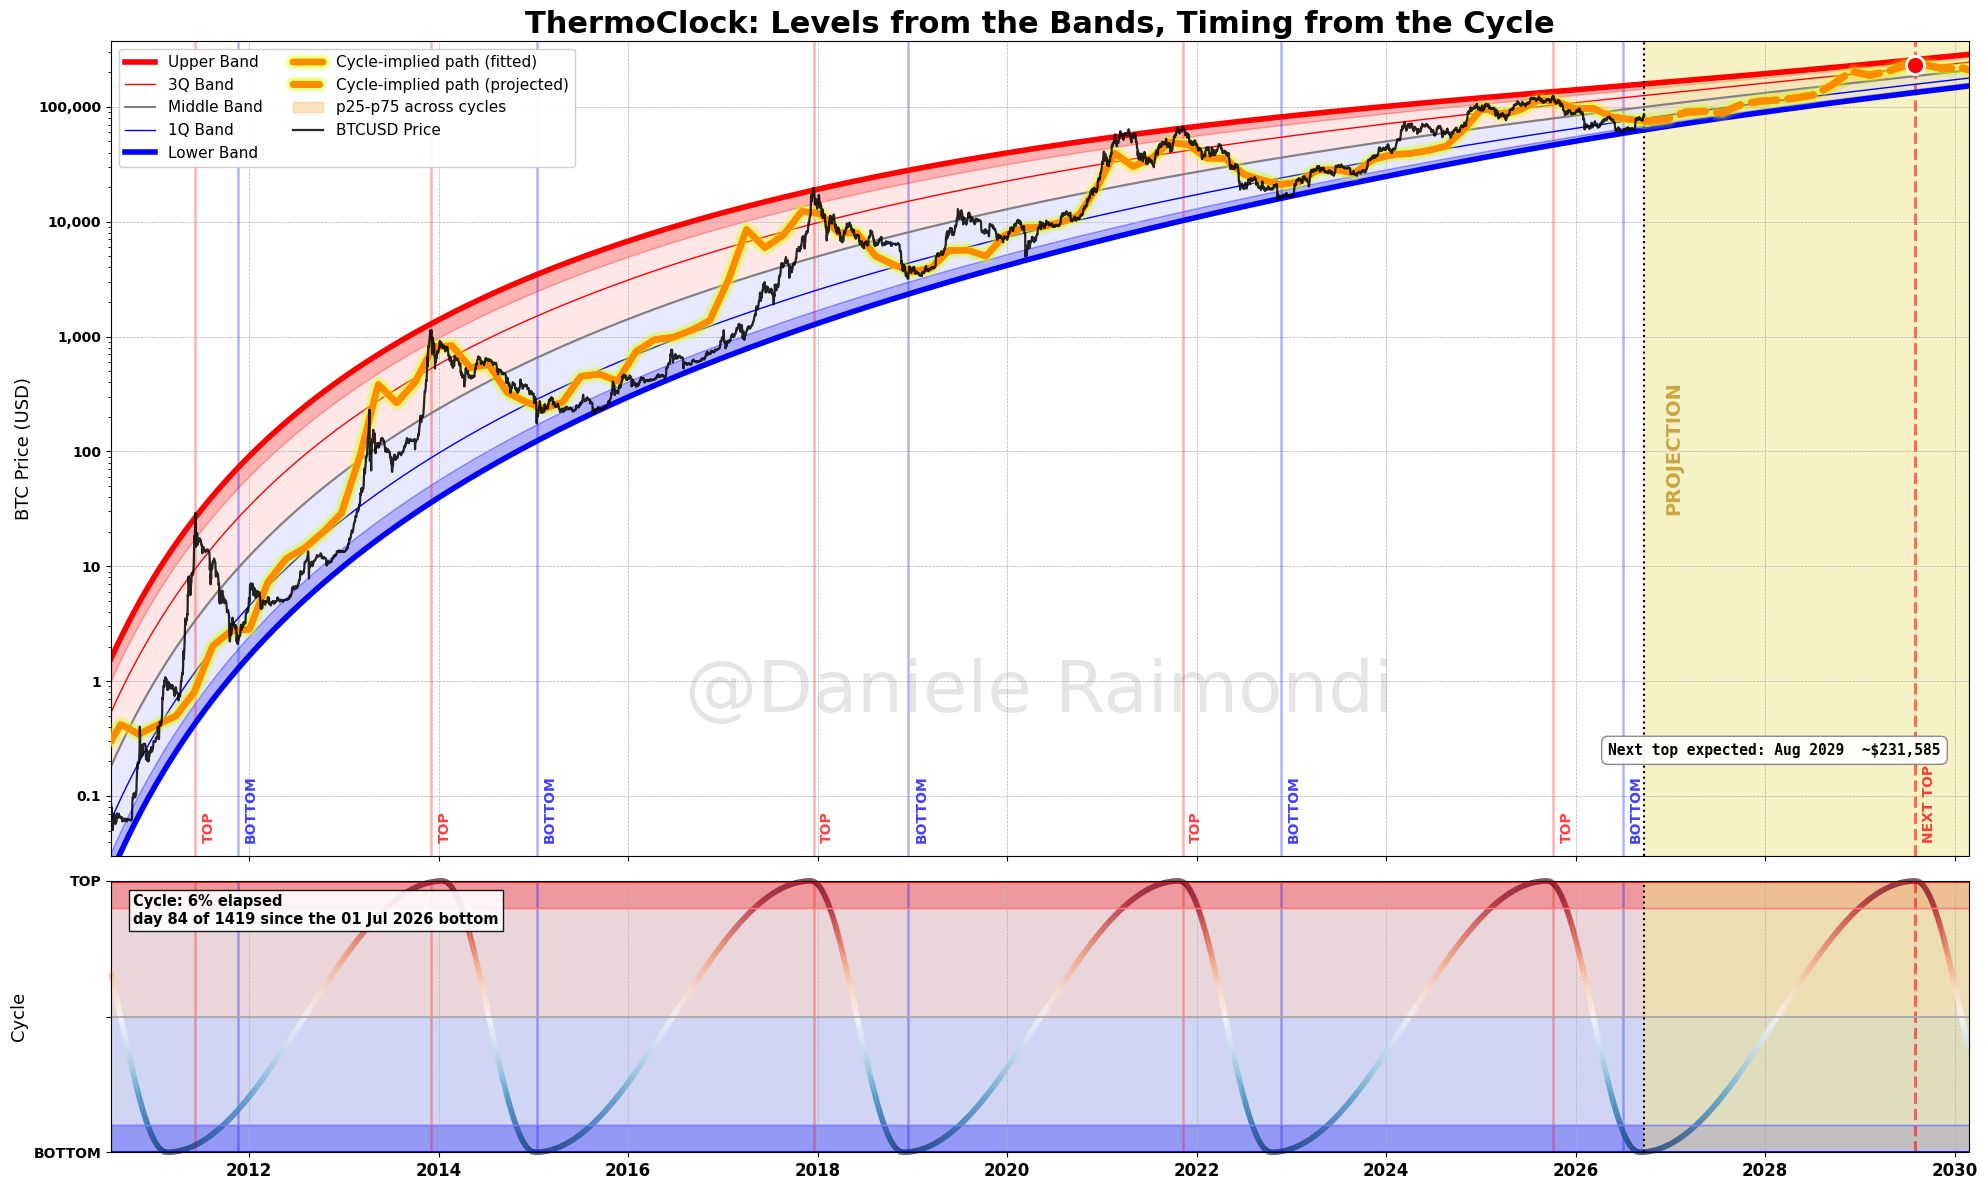

In [2]:
plot_cycle_forecast(df_cycle)

In [3]:
cycle_calls(df_cycle)

ThermoClock: one fixed period for every cycle - 1419 days, fitted by least squares
on the tops and bottoms since 2013 (the 2011 cycle, 910 days top to top, is left out
as the outlier). Each bottom sits a quarter of a cycle after its top (phase 0.25).

How close the clock lands on the extremes it was fitted to:
   top    Dec 2013  ->  clock says Jan 2014    43 days late
   bottom Jan 2015  ->  clock says Jan 2015     8 days early
   top    Dec 2017  ->  clock says Dec 2017    11 days early
   bottom Dec 2018  ->  clock says Nov 2018    19 days early
   top    Nov 2021  ->  clock says Oct 2021    15 days early
   bottom Nov 2022  ->  clock says Oct 2022    37 days early
   top    Oct 2025  ->  clock says Sep 2025    22 days early
   bottom Jul 2026  ->  clock says Sep 2026    65 days late

Today (2026-09-23): day 84 since the 2026-07-01 bottom - 6% of a 1419-day cycle.

Cycle BOTTOM (confirmed): July 2026
   actual price:      $60,004
   corridor then:     $58,729 - $152,058

Next cycle 